In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [160]:
data = pd.read_json("results/bm_prefill_cpu.json")

print(data["device_count"].value_counts())

data

device_count
1    1000
2    1000
4     384
Name: count, dtype: int64


,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,total_generated_tokens,yield_count
0,2025-09-24 02:45:27.411668539,21.686493,1,8829,8192,1,False,0.896937,1,16
1,2025-09-24 02:45:40.070995808,10.266074,1,6234,8192,1,False,0.794350,1,12
2,2025-09-24 02:45:42.790407896,0.280352,1,666,8192,1,False,0.928671,1,17
3,2025-09-24 02:45:56.815092564,11.723241,1,6549,8192,1,False,0.669516,1,10
4,2025-09-24 02:46:01.053483248,1.784840,1,2378,8192,1,False,0.858198,1,17
...,...,...,...,...,...,...,...,...,...,...
2379,2025-09-24 12:37:13.952811241,15.785773,4,8184,8192,1,False,0.034921,1,9
2380,2025-09-24 12:37:56.721318245,9.758370,4,6344,8192,1,False,0.673570,1,50
2381,2025-09-24 12:38:28.233956337,7.589653,4,5674,8192,1,False,0.094448,1,12
2382,2025-09-24 12:39:31.619097233,15.752076,4,7359,8192,1,False,0.649464,1,54


/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packa

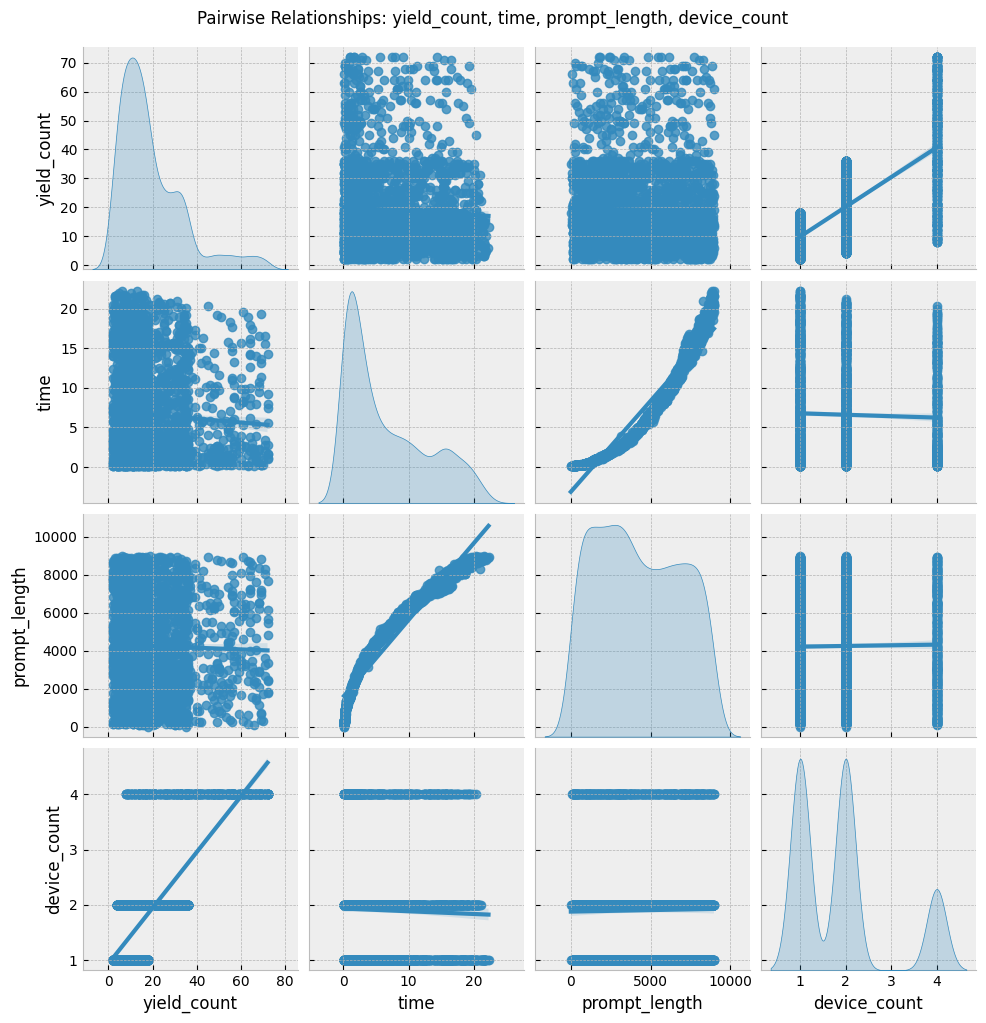

Correlation matrix:
                yield_count      time  prompt_length  device_count
yield_count       1.000000 -0.057590      -0.024612      0.720763
time             -0.057590  1.000000       0.963815     -0.029802
prompt_length    -0.024612  0.963815       1.000000      0.013794
device_count      0.720763 -0.029802       0.013794      1.000000


In [161]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "prompt_length", "device_count"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, prompt_length, device_count", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

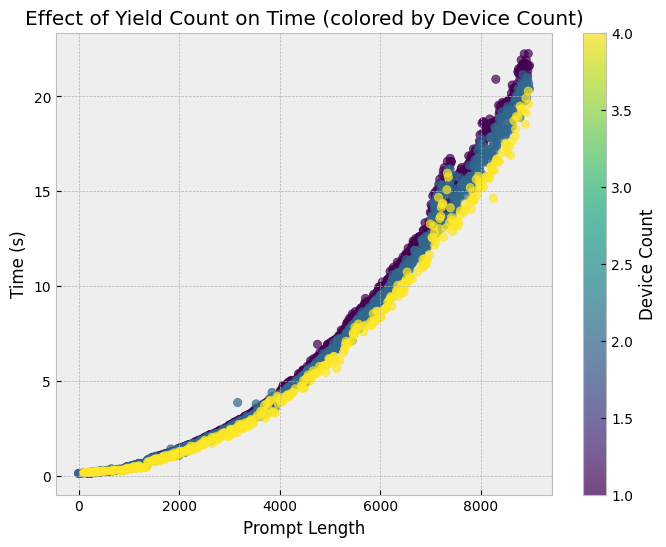

In [162]:
# Scatter plot: yield_count vs time, colored by prompt_length
plt.figure(figsize=(8, 6))
sc = plt.scatter(data["prompt_length"], data["time"], c=data["device_count"], cmap="viridis", alpha=0.7)
plt.xlabel("Prompt Length")
plt.ylabel("Time (s)")
plt.title("Effect of Yield Count on Time (colored by Device Count)")
cbar = plt.colorbar(sc)
cbar.set_label("Device Count")
plt.show()

In [163]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

scaler = MinMaxScaler()
df = data.copy()
df["prompt_length_sq"] = df["prompt_length"]**2
X_raw = df[["prompt_length", "prompt_length_sq", "yield_count", "device_count", "time"]]
X_norm = scaler.fit_transform(X_raw)

X1 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length"]]
X2 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq"]]
X3 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq", "yield_count"]]
X4 = pd.DataFrame(X_norm, columns=X_raw.columns)[["prompt_length", "prompt_length_sq", "yield_count", "device_count"]]
y = X_raw["time"]

X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

print(model4.summary())
print("F-test p-value for adding device_count:", model4.compare_f_test(model3)[1])
print("F-test p-value for adding yield_count:", model3.compare_f_test(model2)[1])
print("F-test p-value for adding prompt_length_sq:", model2.compare_f_test(model1)[1])

print("R-squared values:")
print("Model 1 (prompt_length):", model1.rsquared)
print("Model 2 (prompt_length + prompt_length_sq):", model2.rsquared)
print("Model 3 (prompt_length + prompt_length_sq + yield_count):", model3.rsquared)
print("Model 4 (prompt_length + prompt_length_sq + yield_count + device_count):", model4.rsquared)

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.329e+05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:27:11   Log-Likelihood:                -1277.2
No. Observations:                2384   AIC:                             2564.
Df Residuals:                    2379   BIC:                             2593.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4438      0.026  

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.329e+05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:27:11   Log-Likelihood:                -1277.2
No. Observations:                2384   AIC:                             2564.
Df Residuals:                    2379   BIC:                             2593.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4438      0.026  

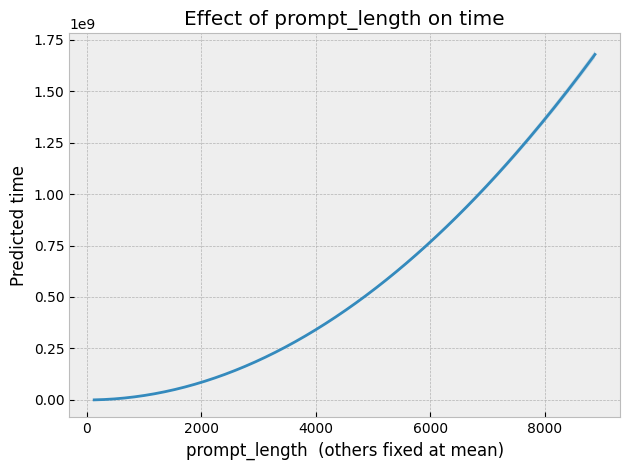

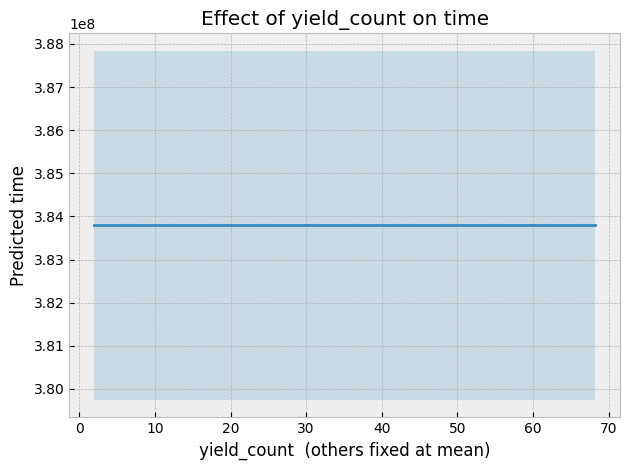

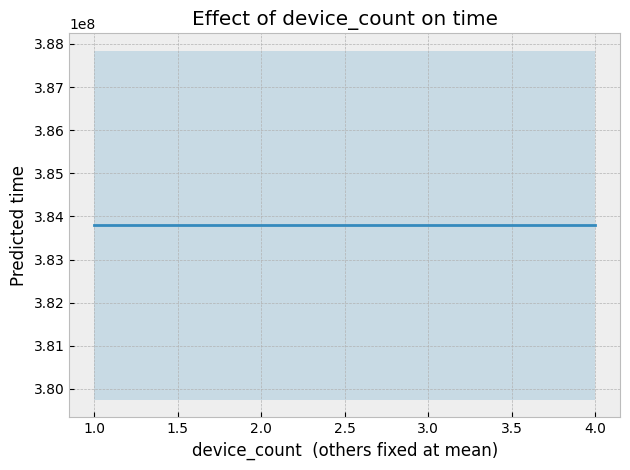

In [164]:
# pip install pandas numpy statsmodels matplotlib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assume df already has: time, prompt_length, yield_count
df = data.copy()

# ------------------------------------------------------------
# 1) Add quadratic terms
# ------------------------------------------------------------
df["prompt_length_sq"] = df["prompt_length"]**2

# ------------------------------------------------------------
# 2) Fit quadratic OLS model
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_raw = df[["prompt_length", "yield_count", "prompt_length_sq", "device_count"]]
X_norm = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_norm, columns=X_raw.columns)
X = sm.add_constant(X)
y = df["time"]

quad_model = sm.OLS(y, X).fit()
print(quad_model.summary())

# ------------------------------------------------------------
# 3) Effect plot for prompt_length (quadratic)
# ------------------------------------------------------------
def quadratic_effect_plot(var_name, hold_vars, n=200):
    hold_vals = {k: df[k].mean() for k in hold_vars}
    vmin, vmax = np.percentile(df[var_name], [1, 99])
    grid = np.linspace(vmin, vmax, n)

    design = pd.DataFrame({
        "const": 1.0,
        "prompt_length": grid if var_name == "prompt_length" else hold_vals["prompt_length"],
        "yield_count": grid if var_name == "yield_count" else hold_vals["yield_count"],
        "prompt_length_sq": (grid if var_name == "prompt_length" else hold_vals["prompt_length"])**2,
        "device_count": grid if var_name == "device_count" else hold_vals["device_count"],
    })

    pred_res = quad_model.get_prediction(design).summary_frame(alpha=0.05)

    plt.figure()
    plt.plot(grid, pred_res["mean"])
    plt.fill_between(grid, pred_res["mean_ci_lower"], pred_res["mean_ci_upper"], alpha=0.2)
    plt.xlabel(var_name + f"  (others fixed at mean)")
    plt.ylabel("Predicted time")
    plt.title(f"Effect of {var_name} on time")
    plt.tight_layout()
    plt.show()

quadratic_effect_plot("prompt_length", ["yield_count", "device_count"])
quadratic_effect_plot("yield_count", ["prompt_length", "device_count"])
quadratic_effect_plot("device_count", ["prompt_length", "yield_count"])


Permutation Importance (Global Sensitivity):
prompt_length_sq    79.059926
device_count         0.207245
prompt_length        0.025464
yield_count          0.008393
dtype: float64


/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-b

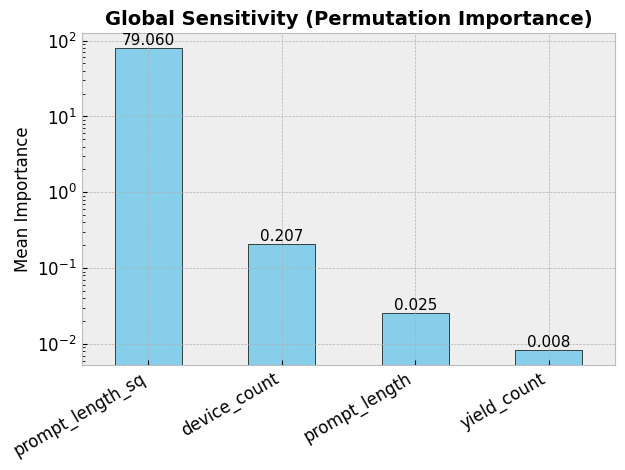

In [168]:
from sklearn.inspection import permutation_importance

# Fit a linear regression model for sensitivity analysis
lr = LinearRegression()
lr.fit(X_raw, y)

# Permutation importance (global sensitivity)
result = permutation_importance(lr, X_raw, y, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Display results
importances = pd.Series(result.importances_mean, index=X_raw.columns)
importances = importances.sort_values(ascending=False)
print("Permutation Importance (Global Sensitivity):")
print(importances)

ax = importances.plot(kind='bar', title='Global Sensitivity (Permutation Importance)', color='skyblue', edgecolor='black')
plt.ylabel('Mean Importance')
plt.yscale('log')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Global Sensitivity (Permutation Importance)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Annotate bars with values
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', rotation=0)

plt.show()


In [170]:
from SALib.sample import saltelli
from SALib.analyze import sobol

# Sobol sensitivity analysis requires the SALib library and a suitable problem definition.

# Define the problem for SALib
problem = {
    'num_vars': X_raw.shape[1],
    'names': list(X_raw.columns),
    'bounds': [[float(X_raw[c].min()), float(X_raw[c].max())] for c in X_raw.columns]
}

# Generate samples
param_values = saltelli.sample(problem, 1024, calc_second_order=False)

# Fit a model to the original data
lr = LinearRegression()
lr.fit(X_raw, y)

# Predict using the model for the sampled parameter values
y_sobol = lr.predict(param_values)

# Perform Sobol sensitivity analysis
sobol_indices = sobol.analyze(problem, y_sobol, calc_second_order=False, print_to_console=True)

# Display first-order and total-order indices
sobol_df = pd.DataFrame({
    'S1': sobol_indices['S1'],
    'S1_conf': sobol_indices['S1_conf'],
    'ST': sobol_indices['ST'],
    'ST_conf': sobol_indices['ST_conf']
}, index=problem['names'])
print(sobol_df)

                        ST   ST_conf
prompt_length     0.000333  0.000030
yield_count       0.000219  0.000020
prompt_length_sq  0.997487  0.060485
device_count      0.001949  0.000176
                        S1   S1_conf
prompt_length     0.000334  0.001635
yield_count       0.000219  0.001358
prompt_length_sq  0.997489  0.075129
device_count      0.001946  0.004057
                        S1   S1_conf        ST   ST_conf
prompt_length     0.000334  0.001635  0.000333  0.000030
yield_count       0.000219  0.001358  0.000219  0.000020
prompt_length_sq  0.997489  0.075129  0.997487  0.060485
device_count      0.001946  0.004057  0.001949  0.000176


/var/folders/ym/j7xrj8pj0vlfstnbbgqq1vt00000gn/T/ipykernel_37846/1916792236.py:14: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=False)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: in